In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import datetime

In [ ]:
# ============================================================
# CELL 1 — Mount Drive, imports, your paths
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from itertools import chain
import numpy as np
import os, glob

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --- YOUR PATHS ---
noisy_path = '/content/drive/MyDrive/train/train/NoisyLR'
gt_path    = '/content/drive/MyDrive/train/train/GT'
ckpt_dir   = '/content/drive/MyDrive/train/checkpoints'
os.makedirs(ckpt_dir, exist_ok=True)

In [ ]:
noisy_files = sorted(glob.glob(os.path.join(noisy_path, "*.npy")))
gt_files    = sorted(glob.glob(os.path.join(gt_path, "*.npy")))
print(f"Noisy files found: {len(noisy_files)}   GT files found: {len(gt_files)}")

shapes_noisy, mins, maxs = set(), [], []
for f in noisy_files[:50]:
    arr = np.load(f)
    shapes_noisy.add(arr.shape)
    mins.append(arr.min()); maxs.append(arr.max())

shapes_gt = set(np.load(f).shape for f in gt_files[:50])

print("Noisy shapes seen (sample of 50):", shapes_noisy)
print("GT shapes seen (sample of 50):", shapes_gt)
print("Noisy dtype:", np.load(noisy_files[0]).dtype)
print(f"Noisy value range in sample: [{min(mins):.3f}, {max(maxs):.3f}]")

In [ ]:
# ============================================================
# CELL 3 — Dataset class + split/bucket helpers
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os, glob

class RestorationDataset(Dataset):
    """Loads paired (noisy_LR, gt_HR) .npy arrays and returns them as tensors."""
    def __init__(self, noisy_dir, gt_dir, filenames, augment=False, scale=1.0):
        self.noisy_dir = noisy_dir
        self.gt_dir = gt_dir
        self.filenames = filenames
        self.augment = augment
        self.scale = scale   # 1.0 for your data — it's already float32, do NOT divide by 255

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fn = self.filenames[idx]
        noisy = np.load(os.path.join(self.noisy_dir, fn)).astype(np.float32) / self.scale
        gt    = np.load(os.path.join(self.gt_dir, fn)).astype(np.float32) / self.scale

        noisy = torch.from_numpy(noisy).unsqueeze(0)   # add channel dim -> (1, H, W)
        gt    = torch.from_numpy(gt).unsqueeze(0)

        if self.augment:
            if torch.rand(1).item() < 0.5:
                noisy, gt = torch.flip(noisy, [2]), torch.flip(gt, [2])
            if torch.rand(1).item() < 0.5:
                noisy, gt = torch.flip(noisy, [1]), torch.flip(gt, [1])
            k = torch.randint(0, 4, (1,)).item()
            noisy, gt = torch.rot90(noisy, k, [1, 2]), torch.rot90(gt, k, [1, 2])

        return noisy.contiguous(), gt.contiguous()


def build_split(noisy_dir, gt_dir, val_frac=0.1, seed=42):
    """Finds filenames present in BOTH folders, then splits into train/val."""
    noisy_set = set(os.path.basename(f) for f in glob.glob(os.path.join(noisy_dir, "*.npy")))
    gt_set    = set(os.path.basename(f) for f in glob.glob(os.path.join(gt_dir, "*.npy")))
    filenames = sorted(noisy_set & gt_set)
    missing = noisy_set.symmetric_difference(gt_set)
    if missing:
        print(f"Warning: {len(missing)} files present in only one folder — ignored.")

    rng = np.random.default_rng(seed)
    shuffled = list(rng.permutation(filenames))
    n_val = max(1, int(len(shuffled) * val_frac))
    return shuffled[n_val:], shuffled[:n_val]


def bucket_by_shape(noisy_dir, filenames):
    """Groups filenames by input resolution so a DataLoader batch never mixes sizes."""
    buckets = {}
    for fn in filenames:
        shape = np.load(os.path.join(noisy_dir, fn)).shape
        buckets.setdefault(shape, []).append(fn)
    return buckets

print("Cell 3 loaded: RestorationDataset, build_split, bucket_by_shape defined.")

In [ ]:
# ============================================================
# CELL 4 — Model: U-Net with global residual connection
# ============================================================
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
            )
        self.enc1 = conv_block(1, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = conv_block(128, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)
        self.final_up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x); p1 = self.pool1(s1)
        s2 = self.enc2(p1); p2 = self.pool2(s2)
        b = self.bottleneck(p2)
        d2 = self.dec2(torch.cat([self.up2(b), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))
        residual = self.final_conv(self.final_up(d1))
        base = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        return base + residual   # network learns the correction, not raw pixels


class SobelGradLoss(nn.Module):
    """Penalizes edge-map differences so restorations stay sharp, not smoothed."""
    def __init__(self):
        super().__init__()
        kx = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32).view(1,1,3,3)
        ky = kx.transpose(2, 3)
        self.register_buffer('kx', kx)
        self.register_buffer('ky', ky)

    def forward(self, pred, target):
        gx_p = F.conv2d(pred, self.kx, padding=1); gy_p = F.conv2d(pred, self.ky, padding=1)
        gx_t = F.conv2d(target, self.kx, padding=1); gy_t = F.conv2d(target, self.ky, padding=1)
        return F.l1_loss(gx_p, gx_t) + F.l1_loss(gy_p, gy_t)


def psnr(pred, target, max_val=1.0):
    mse = F.mse_loss(pred, target)
    return 10 * torch.log10(max_val**2 / mse) if mse > 0 else torch.tensor(float('inf'))

print("Cell 4 loaded: UNet, SobelGradLoss, psnr defined.")

In [ ]:
# ============================================================
# CELL 5 — Config + build data loaders
# Uses noisy_path / gt_path / ckpt_dir / device from Cell 1 — run Cell 1 first.
# ============================================================
from itertools import chain
import torch.optim as optim
noisy_path = '/content/drive/MyDrive/train/train/NoisyLR'
gt_path    = '/content/drive/MyDrive/train/train/GT'
ckpt_dir   = '/content/drive/MyDrive/train/checkpoints'

SCALE = 1.0          # your data is already float32 in [-0.08, 1.71] — do NOT rescale
BATCH_SIZE = 16
NUM_EPOCHS = 30

train_files, val_files = build_split(noisy_path, gt_path, val_frac=0.1)
print(f"train={len(train_files)}  val={len(val_files)}")

def make_loaders(filenames, augment, shuffle, num_workers):
    buckets = bucket_by_shape(noisy_path, filenames)
    loaders = []
    for shape, files in buckets.items():
        ds = RestorationDataset(noisy_path, gt_path, files, augment=augment, scale=SCALE)
        loaders.append(DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                                   num_workers=num_workers, pin_memory=True))
        print(f"  shape {shape}: {len(files)} images")
    return loaders

print("Train buckets:")
train_loaders = make_loaders(train_files, augment=True, shuffle=True, num_workers=4)
print("Val buckets:")
val_loaders = make_loaders(val_files, augment=False, shuffle=False, num_workers=2)

model = UNet().to(device)
l1 = nn.L1Loss()
grad_loss_fn = SobelGradLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler = torch.amp.GradScaler('cuda')

print("Cell 5 done: model, loaders, optimizer ready.")

In [ ]:
# ============================================================
# CELL 6 — Train (checkpoints saved to Drive every epoch)
# ============================================================
best_val_psnr = -float('inf')
n_train_batches = sum(len(l) for l in train_loaders)
n_val_batches = sum(len(l) for l in val_loaders)

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0
    for noisy, gt in chain(*train_loaders):
        noisy, gt = noisy.to(device, non_blocking=True), gt.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            output = model(noisy)
            loss = l1(output, gt) + 0.1 * grad_loss_fn(output, gt)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
    scheduler.step()

    model.eval()
    val_psnr_total = 0
    with torch.no_grad():
        for noisy, gt in chain(*val_loaders):
            noisy, gt = noisy.to(device), gt.to(device)
            with torch.amp.autocast('cuda'):
                output = model(noisy)
            val_psnr_total += psnr(output.float().clamp(0, 1), gt.float()).item()
    val_psnr = val_psnr_total / n_val_batches

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {train_loss/n_train_batches:.4f} "
          f"Val PSNR: {val_psnr:.2f}dB  LR: {scheduler.get_last_lr()[0]:.2e}")

    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(), 'val_psnr': val_psnr},
               os.path.join(ckpt_dir, 'last_checkpoint.pth'))

    if val_psnr > best_val_psnr:
        best_val_psnr = val_psnr
        torch.save(model.state_dict(), os.path.join(ckpt_dir, 'best_model.pth'))
        print(f"  -> new best saved ({val_psnr:.2f}dB)")

print("Done. Best val PSNR:", best_val_psnr)
print("Model saved at:", os.path.join(ckpt_dir, 'best_model.pth'))

In [16]:
# ============================================================
# CELL 1 — Google Drive + Imports
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os, glob, random, time
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim_fn
# if skimage import fails: !pip install scikit-image -q

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [17]:
# ============================================================
# CELL 2 — Configuration (every hyperparameter lives here)
# ============================================================
CONFIG = {
    # paths — ASSUMED from earlier setup, change if different
    'NOISY_DIR': '/content/drive/MyDrive/train/train/NoisyLR',
    'GT_DIR':    '/content/drive/MyDrive/train/train/GT',
    'PRETRAINED_PATH': '/content/drive/MyDrive/train/checkpoints/best_model.pth',
    'BASELINE_CKPT_DIR':   '/content/drive/MyDrive/train/checkpoints_exp/baseline',
    'EXPERIMENT_CKPT_DIR': '/content/drive/MyDrive/train/checkpoints_exp/random_crop',

    # data
    'NOISY_SIZE': 128,
    'GT_SIZE': 256,
    'SCALE': 2,                # GT is 2x NoisyLR resolution
    'VAL_FRAC': 0.1,

    # crop augmentation
    'CROP_SIZE': 64,           # noisy-side crop size; GT crop = CROP_SIZE * SCALE
    'CROPS_PER_IMAGE': 2,      # two independent random crops per training pair, per spec

    # training
    'BATCH_SIZE': 16,          # per your own observation: bs16 outperformed bs64
    'EPOCHS': 30,
    'LEARNING_RATE': 1e-4,     # used only if training from scratch
    'FINETUNE_LR': 2e-5,       # used since we're starting from a pretrained checkpoint
    'WEIGHT_DECAY': 1e-4,
    'LAMBDA_GRADIENT': 0.1,
    'NUM_WORKERS': 2,          # adjust to your actual CPU core count
    'SEED': 42,
}

assert CONFIG['GT_SIZE'] == CONFIG['NOISY_SIZE'] * CONFIG['SCALE'], \
    "GT size must be exactly SCALE times NoisyLR size — check your data."
assert CONFIG['CROP_SIZE'] <= CONFIG['NOISY_SIZE'], \
    "CROP_SIZE cannot exceed the full NoisyLR image size."

os.makedirs(CONFIG['BASELINE_CKPT_DIR'], exist_ok=True)
os.makedirs(CONFIG['EXPERIMENT_CKPT_DIR'], exist_ok=True)

print("--- Why batch size 16 over 64 (per your observation) ---")
print("Smaller batches inject more gradient noise per step. That noise acts as an")
print("implicit regularizer — it nudges optimization away from sharp, narrow minima")
print("that fit training data closely but generalize poorly, toward flatter minima")
print("that tend to generalize better. Larger batches give smoother, more 'confident'")
print("gradient estimates, which can converge faster but into sharper minima —")
print("especially relevant here since LR wasn't scaled up to compensate for bs=64.")

print("\n--- Why FINETUNE_LR is lower than a from-scratch LR ---")
print("This checkpoint already converged to ~25.7dB. Restarting at a high LR would")
print("push the weights hard for several epochs before settling — effectively")
print("partially re-randomizing a model that already learned something useful.")
print("A smaller LR nudges existing weights toward the new augmented data")
print("distribution instead of overwriting them.")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True   # trade strict determinism for speed
    # for bit-exact determinism instead, set benchmark=False and cudnn.deterministic=True

def worker_init_fn(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

print("\nConfig loaded.")

--- Why batch size 16 over 64 (per your observation) ---
Smaller batches inject more gradient noise per step. That noise acts as an
implicit regularizer — it nudges optimization away from sharp, narrow minima
that fit training data closely but generalize poorly, toward flatter minima
that tend to generalize better. Larger batches give smoother, more 'confident'
gradient estimates, which can converge faster but into sharper minima —
especially relevant here since LR wasn't scaled up to compensate for bs=64.

--- Why FINETUNE_LR is lower than a from-scratch LR ---
This checkpoint already converged to ~25.7dB. Restarting at a high LR would
push the weights hard for several epochs before settling — effectively
partially re-randomizing a model that already learned something useful.
A smaller LR nudges existing weights toward the new augmented data
distribution instead of overwriting them.

Config loaded.


In [19]:
# ============================================================
# CELL 3 — Dataset Inspection (diagnostic, run before anything else)
# ============================================================
noisy_files = sorted(glob.glob(os.path.join(CONFIG['NOISY_DIR'], "*.npy")))
gt_files    = sorted(glob.glob(os.path.join(CONFIG['GT_DIR'], "*.npy")))

noisy_names = set(os.path.basename(f) for f in noisy_files)
gt_names    = set(os.path.basename(f) for f in gt_files)
common_names = sorted(noisy_names & gt_names)
mismatched = noisy_names.symmetric_difference(gt_names)

print(f"NoisyLR files found: {len(noisy_files)}")
print(f"GT files found:      {len(gt_files)}")
print(f"Matching pairs:      {len(common_names)}")
print(f"Mismatched (in only one folder): {len(mismatched)}")

sample = np.load(os.path.join(CONFIG['NOISY_DIR'], common_names[0]))
sample_gt = np.load(os.path.join(CONFIG['GT_DIR'], common_names[0]))
print(f"\nNoisy shape: {sample.shape}  dtype: {sample.dtype}")
print(f"GT shape:    {sample_gt.shape}  dtype: {sample_gt.dtype}")

n_min, n_max = float('inf'), float('-inf')
g_min, g_max = float('inf'), float('-inf')
for fn in common_names:
    n = np.load(os.path.join(CONFIG['NOISY_DIR'], fn), mmap_mode='r')
    g = np.load(os.path.join(CONFIG['GT_DIR'], fn), mmap_mode='r')
    n_min, n_max = min(n_min, n.min()), max(n_max, n.max())
    g_min, g_max = min(g_min, g.min()), max(g_max, g.max())

print(f"\nNoisy full-dataset range: [{n_min:.4f}, {n_max:.4f}]")
print(f"GT full-dataset range:    [{g_min:.4f}, {g_max:.4f}]")

NoisyLR files found: 3200
GT files found:      3200
Matching pairs:      3200
Mismatched (in only one folder): 0

Noisy shape: (128, 128)  dtype: float32
GT shape:    (256, 256)  dtype: float32

Noisy full-dataset range: [-0.2786, 2.1580]
GT full-dataset range:    [0.0000, 1.0000]


In [20]:
# ============================================================
# CELL 4 — Train/Validation Split
# ============================================================
set_seed(CONFIG['SEED'])
rng = np.random.default_rng(CONFIG['SEED'])
shuffled = list(rng.permutation(common_names))
n_val = max(1, int(len(shuffled) * CONFIG['VAL_FRAC']))
val_files = shuffled[:n_val]
train_files = shuffled[n_val:]

print(f"Training pairs:   {len(train_files)}")
print(f"Validation pairs: {len(val_files)}")

Training pairs:   2880
Validation pairs: 320


In [21]:
# ============================================================
# CELL 5 — Paired Random Crop Dataset + Full-Image Dataset
# ============================================================
class FullPairDataset(Dataset):
    """Full-resolution pairs, no cropping, no augmentation.
    Used for baseline training AND for validation."""
    def __init__(self, noisy_dir, gt_dir, filenames):
        self.noisy_dir = noisy_dir
        self.gt_dir = gt_dir
        self.filenames = filenames

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fn = self.filenames[idx]
        noisy = np.load(os.path.join(self.noisy_dir, fn)).astype(np.float32)
        gt = np.load(os.path.join(self.gt_dir, fn)).astype(np.float32)
        return torch.from_numpy(noisy).unsqueeze(0), torch.from_numpy(gt).unsqueeze(0)


class PairedRandomCropDataset(Dataset):
    """Random paired crops. GT crop coordinates are ALWAYS derived from the
    noisy crop coordinates (scaled by SCALE) — never cropped independently.
    Dataset length = num_files * crops_per_image, so each source pair
    contributes multiple independent random crops per epoch."""
    def __init__(self, noisy_dir, gt_dir, filenames, crop_size, scale,
                 crops_per_image=2, augment_flip=True):
        self.noisy_dir = noisy_dir
        self.gt_dir = gt_dir
        self.filenames = filenames
        self.crop_size = crop_size
        self.scale = scale
        self.crops_per_image = crops_per_image
        self.augment_flip = augment_flip

    def __len__(self):
        return len(self.filenames) * self.crops_per_image

    def __getitem__(self, idx):
        file_idx = idx // self.crops_per_image
        fn = self.filenames[file_idx]

        noisy = np.load(os.path.join(self.noisy_dir, fn)).astype(np.float32)
        gt = np.load(os.path.join(self.gt_dir, fn)).astype(np.float32)

        h, w = noisy.shape
        max_x = w - self.crop_size
        max_y = h - self.crop_size
        x = np.random.randint(0, max_x + 1)
        y = np.random.randint(0, max_y + 1)

        noisy_crop = noisy[y:y + self.crop_size, x:x + self.crop_size]

        gt_crop_size = self.crop_size * self.scale
        gy, gx = y * self.scale, x * self.scale
        gt_crop = gt[gy:gy + gt_crop_size, gx:gx + gt_crop_size]

        noisy_t = torch.from_numpy(noisy_crop.copy()).unsqueeze(0)
        gt_t = torch.from_numpy(gt_crop.copy()).unsqueeze(0)

        if self.augment_flip:
            # SAME flip decision applied to BOTH tensors — never independent
            if random.random() < 0.5:
                noisy_t = torch.flip(noisy_t, [2])
                gt_t = torch.flip(gt_t, [2])
            if random.random() < 0.5:
                noisy_t = torch.flip(noisy_t, [1])
                gt_t = torch.flip(gt_t, [1])

        return noisy_t.contiguous(), gt_t.contiguous()

print("Datasets defined: FullPairDataset, PairedRandomCropDataset.")

Datasets defined: FullPairDataset, PairedRandomCropDataset.


Original noisy shape:       (128, 128)
Original GT shape:          (256, 256)
Random noisy crop shape:    (64, 64)
Corresponding GT crop shape: (128, 128)


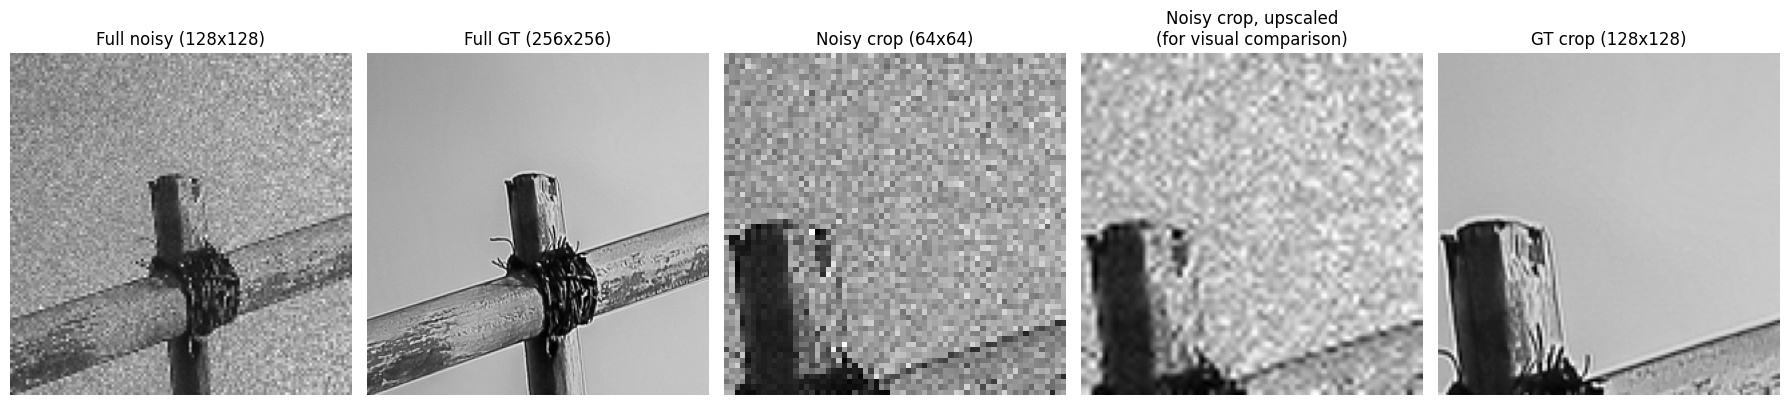


Visually confirm: panels 4 and 5 should show the SAME region — one blurry/upscaled, one sharp GT.


In [22]:
# ============================================================
# CELL 5B — Crop Correspondence Diagnostic + Visual Verification
# ============================================================
_diag_ds = PairedRandomCropDataset(
    CONFIG['NOISY_DIR'], CONFIG['GT_DIR'], train_files,
    crop_size=CONFIG['CROP_SIZE'], scale=CONFIG['SCALE'],
    crops_per_image=CONFIG['CROPS_PER_IMAGE'], augment_flip=False  # no flip, easier to visually confirm
)

fn = train_files[0]
full_noisy = np.load(os.path.join(CONFIG['NOISY_DIR'], fn)).astype(np.float32)
full_gt = np.load(os.path.join(CONFIG['GT_DIR'], fn)).astype(np.float32)
crop_noisy_t, crop_gt_t = _diag_ds[0]
crop_noisy = crop_noisy_t.squeeze().numpy()
crop_gt = crop_gt_t.squeeze().numpy()

print("Original noisy shape:      ", full_noisy.shape)
print("Original GT shape:         ", full_gt.shape)
print("Random noisy crop shape:   ", crop_noisy.shape)
print("Corresponding GT crop shape:", crop_gt.shape)

from PIL import Image
upscaled_crop = np.array(
    Image.fromarray((crop_noisy * 255).clip(0, 255).astype(np.uint8))
    .resize((crop_gt.shape[1], crop_gt.shape[0]))
) / 255.0

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(full_noisy, cmap='gray'); axes[0].set_title('Full noisy (128x128)'); axes[0].axis('off')
axes[1].imshow(full_gt, cmap='gray'); axes[1].set_title('Full GT (256x256)'); axes[1].axis('off')
axes[2].imshow(crop_noisy, cmap='gray'); axes[2].set_title(f'Noisy crop ({crop_noisy.shape[0]}x{crop_noisy.shape[1]})'); axes[2].axis('off')
axes[3].imshow(upscaled_crop, cmap='gray'); axes[3].set_title('Noisy crop, upscaled\n(for visual comparison)'); axes[3].axis('off')
axes[4].imshow(crop_gt, cmap='gray'); axes[4].set_title(f'GT crop ({crop_gt.shape[0]}x{crop_gt.shape[1]})'); axes[4].axis('off')
plt.tight_layout()
plt.show()
print("\nVisually confirm: panels 4 and 5 should show the SAME region — one blurry/upscaled, one sharp GT.")

In [23]:
# ============================================================
# CELL 6 — DataLoaders
# ============================================================
baseline_train_ds = FullPairDataset(CONFIG['NOISY_DIR'], CONFIG['GT_DIR'], train_files)
crop_train_ds = PairedRandomCropDataset(
    CONFIG['NOISY_DIR'], CONFIG['GT_DIR'], train_files,
    crop_size=CONFIG['CROP_SIZE'], scale=CONFIG['SCALE'],
    crops_per_image=CONFIG['CROPS_PER_IMAGE'], augment_flip=True
)
val_ds = FullPairDataset(CONFIG['NOISY_DIR'], CONFIG['GT_DIR'], val_files)

baseline_train_loader = DataLoader(
    baseline_train_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=True,
    num_workers=CONFIG['NUM_WORKERS'], pin_memory=True, worker_init_fn=worker_init_fn)

crop_train_loader = DataLoader(
    crop_train_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=True,
    num_workers=CONFIG['NUM_WORKERS'], pin_memory=True, worker_init_fn=worker_init_fn)

val_loader = DataLoader(
    val_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'], pin_memory=True)

print(f"Baseline train batches:   {len(baseline_train_loader)}  ({len(baseline_train_ds)} samples/epoch)")
print(f"Crop-exp train batches:   {len(crop_train_loader)}  ({len(crop_train_ds)} samples/epoch)")
print(f"Validation batches:       {len(val_loader)}  ({len(val_ds)} samples)")
print("\nNote: crop-experiment has more samples/epoch than baseline by design —")
print("that's the augmentation itself, not a bug. Both see the same source images.")

Baseline train batches:   180  (2880 samples/epoch)
Crop-exp train batches:   360  (5760 samples/epoch)
Validation batches:       20  (320 samples)

Note: crop-experiment has more samples/epoch than baseline by design —
that's the augmentation itself, not a bug. Both see the same source images.


In [24]:
# ============================================================
# CELL 7 — Model Definition (matches your existing best_model.pth exactly)
# ============================================================
class RestorationNet(nn.Module):
    """Must match best_model.pth's saved architecture exactly, or load_state_dict fails."""
    def __init__(self):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
            )
        self.enc1 = conv_block(1, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = conv_block(128, 256)          # name must match checkpoint exactly
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)
        self.final_up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x); p1 = self.pool1(s1)
        s2 = self.enc2(p1); p2 = self.pool2(s2)
        b = self.bottleneck(p2)
        d2 = self.dec2(torch.cat([self.up2(b), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))
        residual = self.final_conv(self.final_up(d1))
        base = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        return base + residual

print("RestorationNet defined — matches your existing best_model.pth checkpoint.")

RestorationNet defined — matches your existing best_model.pth checkpoint.


In [25]:
# ============================================================
# CELL 7B — Load pretrained weights, confirm it worked
# ============================================================
def load_pretrained(model, path, device):
    state_dict = torch.load(path, map_location=device)
    if isinstance(state_dict, dict) and 'model_state_dict' in state_dict:
        state_dict = state_dict['model_state_dict']   # handles either raw or wrapped checkpoint format
    model.load_state_dict(state_dict)   # strict=True by default — errors loudly on any mismatch
    return model

_test_model = RestorationNet().to(device)
load_pretrained(_test_model, CONFIG['PRETRAINED_PATH'], device)
print("Loaded pretrained weights successfully from:", CONFIG['PRETRAINED_PATH'])
del _test_model

Loaded pretrained weights successfully from: /content/drive/MyDrive/train/checkpoints/best_model.pth


In [26]:
# ============================================================
# CELL 8 — Model Shape Verification (STOPS EXECUTION IF WRONG)
# ============================================================
def verify_shapes(model, device):
    tests = [(64, 128), (128, 256)]
    print("Running mandatory shape verification...")
    all_pass = True
    for inp_size, exp_out in tests:
        dummy = torch.zeros(2, 1, inp_size, inp_size).to(device)
        with torch.no_grad():
            out = model(dummy)
        ok = (out.shape[-1] == exp_out and out.shape[-2] == exp_out)
        status = "PASS" if ok else "FAIL"
        print(f"  {inp_size}x{inp_size} -> {out.shape[-2]}x{out.shape[-1]} "
              f"(expected {exp_out}x{exp_out}) [{status}]")
        all_pass = all_pass and ok
    if not all_pass:
        raise RuntimeError(
            "Model shape verification FAILED. This architecture does not produce "
            "genuine 2x super-resolution. Fix before training. Stopping execution."
        )
    print("All checks passed — model performs genuine 2x super-resolution.")

_verify_model = RestorationNet().to(device)
verify_shapes(_verify_model, device)
del _verify_model

Running mandatory shape verification...
  64x64 -> 128x128 (expected 128x128) [PASS]
  128x128 -> 256x256 (expected 256x256) [PASS]
All checks passed — model performs genuine 2x super-resolution.


In [27]:
# ============================================================
# CELL 9 — Loss Functions
# ============================================================
class SobelGradLoss(nn.Module):
    def __init__(self):
        super().__init__()
        kx = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32).view(1,1,3,3)
        ky = kx.transpose(2, 3)
        self.register_buffer('kx', kx)
        self.register_buffer('ky', ky)

    def forward(self, pred, target):
        gx_p = F.conv2d(pred, self.kx, padding=1); gy_p = F.conv2d(pred, self.ky, padding=1)
        gx_t = F.conv2d(target, self.kx, padding=1); gy_t = F.conv2d(target, self.ky, padding=1)
        return F.l1_loss(gx_p, gx_t) + F.l1_loss(gy_p, gy_t)


class CombinedLoss(nn.Module):
    def __init__(self, lambda_gradient=0.1):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.grad_loss = SobelGradLoss()
        self.lambda_gradient = lambda_gradient

    def forward(self, pred, target):
        return self.l1(pred, target) + self.lambda_gradient * self.grad_loss(pred, target)

print("--- Why lambda_gradient = 0.1 ---")
print("L1 drives overall pixel-level reconstruction accuracy; the Sobel gradient term")
print("specifically penalizes edge-map mismatches, discouraging blur. At ~0.1 the")
print("gradient term is influential enough to sharpen edges without dominating L1 —")
print("push it much above ~0.3 and edges can start ringing/over-sharpening; drop it")
print("below ~0.01 and it has almost no effect. Change CONFIG['LAMBDA_GRADIENT'] to tune.")

--- Why lambda_gradient = 0.1 ---
L1 drives overall pixel-level reconstruction accuracy; the Sobel gradient term
specifically penalizes edge-map mismatches, discouraging blur. At ~0.1 the
gradient term is influential enough to sharpen edges without dominating L1 —
push it much above ~0.3 and edges can start ringing/over-sharpening; drop it
below ~0.01 and it has almost no effect. Change CONFIG['LAMBDA_GRADIENT'] to tune.


In [28]:
# ============================================================
# CELL 10 — Optimizer + Scheduler
# ============================================================
def make_optimizer_scheduler(model, config):
    optimizer = optim.AdamW(
        model.parameters(), lr=config['LEARNING_RATE'], weight_decay=config['WEIGHT_DECAY'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['EPOCHS'])
    return optimizer, scheduler

print("Optimizer/scheduler factory ready (AdamW + cosine annealing).")

Optimizer/scheduler factory ready (AdamW + cosine annealing).


In [29]:
# ============================================================
# CELL 11 — Training Loop
# ============================================================
def save_checkpoint(model, optimizer, scheduler, epoch, psnr, ssim, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_psnr': psnr,
        'best_ssim': ssim,
    }, path)


def train_experiment(model, train_loader, val_loader, config, ckpt_dir, experiment_name):
    optimizer, scheduler = make_optimizer_scheduler(model, config)
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())
    criterion = CombinedLoss(lambda_gradient=config['LAMBDA_GRADIENT']).to(device)

    history = {'train_loss': [], 'val_psnr': [], 'val_ssim': [], 'lr': []}
    best_psnr, best_ssim, best_epoch = -float('inf'), 0.0, -1

    for epoch in range(config['EPOCHS']):
        model.train()
        running_loss = 0.0
        for noisy, gt in train_loader:
            noisy, gt = noisy.to(device, non_blocking=True), gt.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                pred = model(noisy)
                loss = criterion(pred, gt)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
        scheduler.step()

        train_loss = running_loss / len(train_loader)
        val_psnr, val_ssim = evaluate(model, val_loader, device)
        current_lr = scheduler.get_last_lr()[0]

        history['train_loss'].append(train_loss)
        history['val_psnr'].append(val_psnr)
        history['val_ssim'].append(val_ssim)
        history['lr'].append(current_lr)

        print(f"[{experiment_name}] Epoch [{epoch+1}/{config['EPOCHS']}] | "
              f"Train Loss: {train_loss:.5f} | "
              f"PSNR: {val_psnr:.3f} dB | "
              f"SSIM: {val_ssim:.5f} | "
              f"LR: {current_lr:.2e}")

        save_checkpoint(model, optimizer, scheduler, epoch, val_psnr, val_ssim,
                         os.path.join(ckpt_dir, 'last_model.pth'))

        if val_psnr > best_psnr:
            best_psnr, best_ssim, best_epoch = val_psnr, val_ssim, epoch + 1
            save_checkpoint(model, optimizer, scheduler, epoch, val_psnr, val_ssim,
                             os.path.join(ckpt_dir, 'best_model.pth'))
            print(f"  --> New best [{experiment_name}]: PSNR {best_psnr:.3f} dB | SSIM {best_ssim:.5f}")

    return history, best_psnr, best_ssim, best_epoch

print("save_checkpoint() and train_experiment() defined.")

save_checkpoint() and train_experiment() defined.


In [30]:
# ============================================================
# CELL 12 — Validation
# ============================================================
def psnr_np(pred, target, max_val=1.0):
    mse = np.mean((pred - target) ** 2)
    return 10 * np.log10(max_val**2 / mse) if mse > 0 else float('inf')

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    psnrs, ssims = [], []
    for noisy, gt in loader:
        noisy, gt = noisy.to(device), gt.to(device)
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            pred = model(noisy)
        pred = pred.float().clamp(0, 1).cpu().numpy()
        gt_np = gt.float().cpu().numpy()
        for i in range(pred.shape[0]):
            p, g = pred[i, 0], gt_np[i, 0]
            psnrs.append(psnr_np(p, g))
            ssims.append(ssim_fn(p, g, data_range=1.0))
    model.train()
    return float(np.mean(psnrs)), float(np.mean(ssims))

print("evaluate() defined.")

evaluate() defined.


In [31]:
# ============================================================
# CELL 13A — Baseline fine-tuning (starts from pretrained, NO augmentation)
# ============================================================
set_seed(CONFIG['SEED'])
baseline_model = RestorationNet().to(device)
load_pretrained(baseline_model, CONFIG['PRETRAINED_PATH'], device)

baseline_config = dict(CONFIG)
baseline_config['LEARNING_RATE'] = CONFIG['FINETUNE_LR']

baseline_history, baseline_best_psnr, baseline_best_ssim, baseline_best_epoch = train_experiment(
    baseline_model, baseline_train_loader, val_loader, baseline_config,
    CONFIG['BASELINE_CKPT_DIR'], "BASELINE (fine-tuned)"
)

[BASELINE (fine-tuned)] Epoch [1/30] | Train Loss: 0.05685 | PSNR: 28.157 dB | SSIM: 0.75873 | LR: 1.99e-05
  --> New best [BASELINE (fine-tuned)]: PSNR 28.157 dB | SSIM 0.75873
[BASELINE (fine-tuned)] Epoch [2/30] | Train Loss: 0.05682 | PSNR: 28.198 dB | SSIM: 0.76052 | LR: 1.98e-05
  --> New best [BASELINE (fine-tuned)]: PSNR 28.198 dB | SSIM 0.76052
[BASELINE (fine-tuned)] Epoch [3/30] | Train Loss: 0.05678 | PSNR: 28.201 dB | SSIM: 0.75877 | LR: 1.95e-05
  --> New best [BASELINE (fine-tuned)]: PSNR 28.201 dB | SSIM 0.75877
[BASELINE (fine-tuned)] Epoch [4/30] | Train Loss: 0.05676 | PSNR: 28.187 dB | SSIM: 0.76023 | LR: 1.91e-05
[BASELINE (fine-tuned)] Epoch [5/30] | Train Loss: 0.05674 | PSNR: 28.201 dB | SSIM: 0.76009 | LR: 1.87e-05
  --> New best [BASELINE (fine-tuned)]: PSNR 28.201 dB | SSIM 0.76009
[BASELINE (fine-tuned)] Epoch [6/30] | Train Loss: 0.05674 | PSNR: 28.213 dB | SSIM: 0.75878 | LR: 1.81e-05
  --> New best [BASELINE (fine-tuned)]: PSNR 28.213 dB | SSIM 0.75878
[B

In [32]:
# ============================================================
# CELL 13B — Random-crop experiment fine-tuning (SAME pretrained start)
# ============================================================
set_seed(CONFIG['SEED'])   # same seed, same starting weights — isolates augmentation as the only variable
crop_model = RestorationNet().to(device)
load_pretrained(crop_model, CONFIG['PRETRAINED_PATH'], device)

crop_config = dict(CONFIG)
crop_config['LEARNING_RATE'] = CONFIG['FINETUNE_LR']

crop_history, crop_best_psnr, crop_best_ssim, crop_best_epoch = train_experiment(
    crop_model, crop_train_loader, val_loader, crop_config,
    CONFIG['EXPERIMENT_CKPT_DIR'], "RANDOM_CROP (fine-tuned)"
)

[RANDOM_CROP (fine-tuned)] Epoch [1/30] | Train Loss: 0.05573 | PSNR: 28.073 dB | SSIM: 0.76027 | LR: 1.99e-05
  --> New best [RANDOM_CROP (fine-tuned)]: PSNR 28.073 dB | SSIM 0.76027
[RANDOM_CROP (fine-tuned)] Epoch [2/30] | Train Loss: 0.05559 | PSNR: 28.085 dB | SSIM: 0.76130 | LR: 1.98e-05
  --> New best [RANDOM_CROP (fine-tuned)]: PSNR 28.085 dB | SSIM 0.76130
[RANDOM_CROP (fine-tuned)] Epoch [3/30] | Train Loss: 0.05566 | PSNR: 28.015 dB | SSIM: 0.76130 | LR: 1.95e-05
[RANDOM_CROP (fine-tuned)] Epoch [4/30] | Train Loss: 0.05565 | PSNR: 28.042 dB | SSIM: 0.76095 | LR: 1.91e-05
[RANDOM_CROP (fine-tuned)] Epoch [5/30] | Train Loss: 0.05537 | PSNR: 28.092 dB | SSIM: 0.76083 | LR: 1.87e-05
  --> New best [RANDOM_CROP (fine-tuned)]: PSNR 28.092 dB | SSIM 0.76083
[RANDOM_CROP (fine-tuned)] Epoch [6/30] | Train Loss: 0.05551 | PSNR: 28.045 dB | SSIM: 0.76155 | LR: 1.81e-05
[RANDOM_CROP (fine-tuned)] Epoch [7/30] | Train Loss: 0.05543 | PSNR: 28.064 dB | SSIM: 0.76127 | LR: 1.74e-05
[RAN

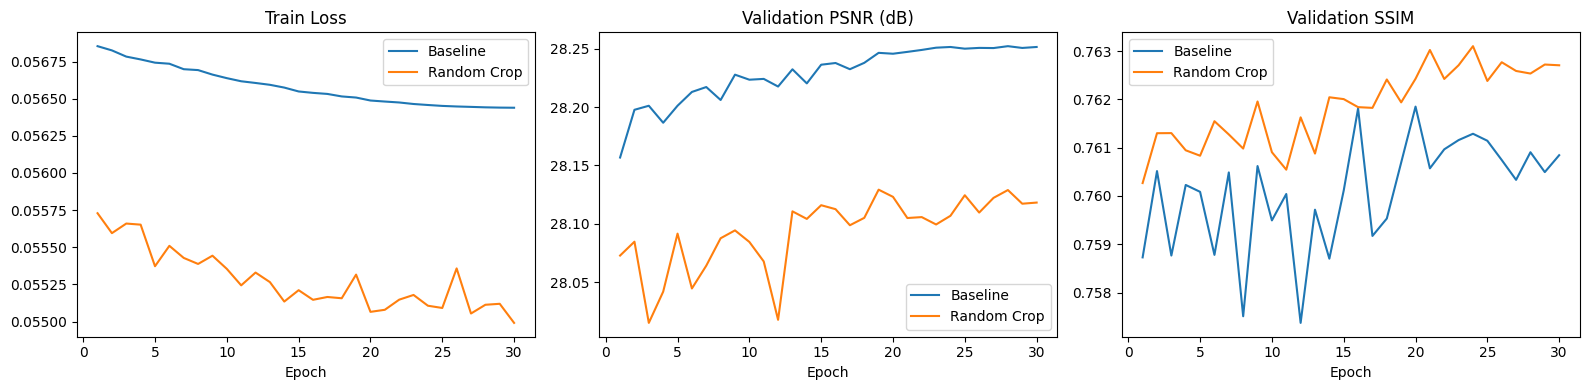

In [33]:
# ============================================================
# CELL 14 — Training Curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_range = range(1, CONFIG['EPOCHS'] + 1)

axes[0].plot(epochs_range, baseline_history['train_loss'], label='Baseline')
axes[0].plot(epochs_range, crop_history['train_loss'], label='Random Crop')
axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs_range, baseline_history['val_psnr'], label='Baseline')
axes[1].plot(epochs_range, crop_history['val_psnr'], label='Random Crop')
axes[1].set_title('Validation PSNR (dB)'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(epochs_range, baseline_history['val_ssim'], label='Baseline')
axes[2].plot(epochs_range, crop_history['val_ssim'], label='Random Crop')
axes[2].set_title('Validation SSIM'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/train/experiment_curves.png', dpi=150)
plt.show()

In [34]:
# ============================================================
# CELL 15 — Best Model Evaluation (independent re-check)
# ============================================================
def load_best(ckpt_dir):
    m = RestorationNet().to(device)
    ckpt = torch.load(os.path.join(ckpt_dir, 'best_model.pth'), map_location=device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    return m

baseline_best_model = load_best(CONFIG['BASELINE_CKPT_DIR'])
crop_best_model = load_best(CONFIG['EXPERIMENT_CKPT_DIR'])

baseline_final_psnr, baseline_final_ssim = evaluate(baseline_best_model, val_loader, device)
crop_final_psnr, crop_final_ssim = evaluate(crop_best_model, val_loader, device)

print(f"Baseline best_model.pth    -> PSNR {baseline_final_psnr:.3f} dB | SSIM {baseline_final_ssim:.5f}")
print(f"Random-crop best_model.pth -> PSNR {crop_final_psnr:.3f} dB | SSIM {crop_final_ssim:.5f}")

Baseline best_model.pth    -> PSNR 28.252 dB | SSIM 0.76091
Random-crop best_model.pth -> PSNR 28.129 dB | SSIM 0.76194


Input shape:  torch.Size([1, 1, 128, 128])
Output shape: torch.Size([1, 1, 256, 256])
Output range: [0.0000, 0.9449]


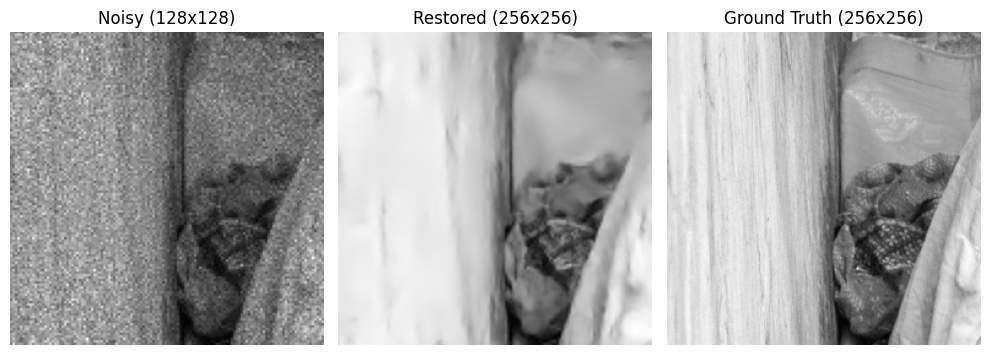

In [35]:
# ============================================================
# CELL 16 — Full 128→256 Inference (using the random-crop fine-tuned model)
# ============================================================
sample_fn = val_files[0]
noisy_full = np.load(os.path.join(CONFIG['NOISY_DIR'], sample_fn)).astype(np.float32)
gt_full = np.load(os.path.join(CONFIG['GT_DIR'], sample_fn)).astype(np.float32)

inp = torch.from_numpy(noisy_full).unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad(), torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
    out = crop_best_model(inp)
out_np = out.float().clamp(0, 1).squeeze().cpu().numpy()

print("Input shape: ", inp.shape)
print("Output shape:", out.shape)
print(f"Output range: [{out_np.min():.4f}, {out_np.max():.4f}]")

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(noisy_full, cmap='gray'); axes[0].set_title('Noisy (128x128)'); axes[0].axis('off')
axes[1].imshow(out_np, cmap='gray'); axes[1].set_title('Restored (256x256)'); axes[1].axis('off')
axes[2].imshow(gt_full, cmap='gray'); axes[2].set_title('Ground Truth (256x256)'); axes[2].axis('off')
plt.tight_layout(); plt.show()

In [37]:
# ============================================================
# CELL 17 — Final Results
# ============================================================
print("="*50)
print("PRETRAINED STARTING POINT (before fine-tuning)")
print("="*50)
print("PSNR: ~25.69 dB  (from original training run)")

print("\n" + "="*50)
print("BASELINE (fine-tuned, no augmentation)")
print("="*50)
print(f"PSNR: {baseline_final_psnr:.3f} dB")
print(f"SSIM: {baseline_final_ssim:.5f}")

print("\n" + "="*50)
print("RANDOM CROP + FLIP EXPERIMENT (fine-tuned)")
print("="*50)
print(f"PSNR: {crop_final_psnr:.3f} dB")
print(f"SSIM: {crop_final_ssim:.5f}")

print("\n" + "="*50)
print("IMPROVEMENT (crop experiment vs baseline)")
print("="*50)
print(f"PSNR change: {crop_final_psnr - baseline_final_psnr:+.3f} dB")
print(f"SSIM change: {crop_final_ssim - baseline_final_ssim:+.5f}")

print("\n--- Experiment metadata ---")
print(f"Started from pretrained: {CONFIG['PRETRAINED_PATH']}")
print(f"Training pairs:          {len(train_files)}")
print(f"Crop size (noisy):       {CONFIG['CROP_SIZE']}x{CONFIG['CROP_SIZE']}")
print(f"Crops per image:         {CONFIG['CROPS_PER_IMAGE']}")
print(f"Batch size:              {CONFIG['BATCH_SIZE']}")
print(f"Epochs:                  {CONFIG['EPOCHS']}")
print(f"Fine-tune learning rate: {CONFIG['FINETUNE_LR']}")
print(f"Loss function:           L1 + {CONFIG['LAMBDA_GRADIENT']} * Sobel gradient loss")
print(f"Architecture:            RestorationNet (matches original best_model.pth)")
print(f"Output truly 2x:         YES (verified in Cell 8)")
print(f"Baseline best epoch:     {baseline_best_epoch}")
print(f"Random-crop best epoch:  {crop_best_epoch}")

PRETRAINED STARTING POINT (before fine-tuning)
PSNR: ~25.69 dB  (from original training run)

BASELINE (fine-tuned, no augmentation)
PSNR: 28.252 dB
SSIM: 0.76091

RANDOM CROP + FLIP EXPERIMENT (fine-tuned)
PSNR: 28.129 dB
SSIM: 0.76194

IMPROVEMENT (crop experiment vs baseline)
PSNR change: -0.123 dB
SSIM change: +0.00103

--- Experiment metadata ---
Started from pretrained: /content/drive/MyDrive/train/checkpoints/best_model.pth
Training pairs:          2880
Crop size (noisy):       64x64
Crops per image:         2
Batch size:              16
Epochs:                  30
Fine-tune learning rate: 2e-05
Loss function:           L1 + 0.1 * Sobel gradient loss
Architecture:            RestorationNet (matches original best_model.pth)
Output truly 2x:         YES (verified in Cell 8)
Baseline best epoch:     28
Random-crop best epoch:  19


second bio inspired style

In [38]:
# ============================================================
# CELL 1 — Google Drive + Imports
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os, glob, random, time
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim_fn
# if skimage import fails: !pip install scikit-image -q

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [39]:
# ============================================================
# CELL 2 — Configuration
# ============================================================
CONFIG = {
    'NOISY_DIR': '/content/drive/MyDrive/train/train/NoisyLR',
    'GT_DIR':    '/content/drive/MyDrive/train/train/GT',
    'PRETRAINED_PATH': '/content/drive/MyDrive/train/checkpoints/best_model.pth',
    'FINAL_CKPT_DIR': '/content/drive/MyDrive/train/checkpoints_exp/biomimetic_final',

    'NOISY_SIZE': 128,
    'GT_SIZE': 256,
    'SCALE': 2,
    'VAL_FRAC': 0.1,

    'CROP_SIZE': 64,
    'CROPS_PER_IMAGE': 2,

    'BATCH_SIZE': 16,
    'EPOCHS': 30,               # consider lowering given deadline pressure — see note below
    'FINETUNE_LR': 2e-5,
    'WEIGHT_DECAY': 1e-4,
    'GRAD_CLIP_NORM': 1.0,
    'NUM_WORKERS': 2,
    'SEED': 42,

    # --- BioMimetic loss weights, exactly as your final formula stated ---
    'LOSS_WEIGHTS': {
        'pixel': 0.45,
        'edge': 0.20,
        'center_surround': 0.20,
        'multiscale': 0.10,
        'ssim': 0.05,
        'foveal': 0.0,          # NOT in your final formula — off by default, flip on to test it
    },
    'CS_SIGMA1': 1.0,           # center Gaussian, narrow
    'CS_SIGMA2': 2.0,           # surround Gaussian, wide — must exceed sigma1
    'FOVEAL_ALPHA': 5.0,        # only matters if 'foveal' weight above is > 0
    'CHARBONNIER_EPS': 1e-3,
}

assert CONFIG['GT_SIZE'] == CONFIG['NOISY_SIZE'] * CONFIG['SCALE']
assert CONFIG['CROP_SIZE'] <= CONFIG['NOISY_SIZE']
assert CONFIG['CS_SIGMA2'] > CONFIG['CS_SIGMA1'], "sigma2 must exceed sigma1 for a valid DoG center-surround filter"

os.makedirs(CONFIG['FINAL_CKPT_DIR'], exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

def worker_init_fn(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

print("Config loaded. EPOCHS =", CONFIG['EPOCHS'],
      "— with 4 days to deadline, consider EPOCHS=15-20 for a faster first pass.")

Config loaded. EPOCHS = 30 — with 4 days to deadline, consider EPOCHS=15-20 for a faster first pass.


In [40]:
# ============================================================
# CELL 3 — Dataset Inspection
# ============================================================
noisy_files = sorted(glob.glob(os.path.join(CONFIG['NOISY_DIR'], "*.npy")))
gt_files    = sorted(glob.glob(os.path.join(CONFIG['GT_DIR'], "*.npy")))
noisy_names = set(os.path.basename(f) for f in noisy_files)
gt_names    = set(os.path.basename(f) for f in gt_files)
common_names = sorted(noisy_names & gt_names)

print(f"NoisyLR files: {len(noisy_files)}  GT files: {len(gt_files)}  Matched pairs: {len(common_names)}")
sample = np.load(os.path.join(CONFIG['NOISY_DIR'], common_names[0]))
sample_gt = np.load(os.path.join(CONFIG['GT_DIR'], common_names[0]))
print(f"Noisy shape: {sample.shape}   GT shape: {sample_gt.shape}")

NoisyLR files: 3200  GT files: 3200  Matched pairs: 3200
Noisy shape: (128, 128)   GT shape: (256, 256)


In [41]:
# ============================================================
# CELL 4 — Train/Validation Split
# ============================================================
set_seed(CONFIG['SEED'])
rng = np.random.default_rng(CONFIG['SEED'])
shuffled = list(rng.permutation(common_names))
n_val = max(1, int(len(shuffled) * CONFIG['VAL_FRAC']))
val_files = shuffled[:n_val]
train_files = shuffled[n_val:]
print(f"Training pairs: {len(train_files)}   Validation pairs: {len(val_files)}")

Training pairs: 2880   Validation pairs: 320


In [42]:
# ============================================================
# CELL 5 — Datasets (full-image + paired random crop)
# ============================================================
class FullPairDataset(Dataset):
    def __init__(self, noisy_dir, gt_dir, filenames):
        self.noisy_dir, self.gt_dir, self.filenames = noisy_dir, gt_dir, filenames

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fn = self.filenames[idx]
        noisy = np.load(os.path.join(self.noisy_dir, fn)).astype(np.float32)
        gt = np.load(os.path.join(self.gt_dir, fn)).astype(np.float32)
        return torch.from_numpy(noisy).unsqueeze(0), torch.from_numpy(gt).unsqueeze(0)


class PairedRandomCropDataset(Dataset):
    def __init__(self, noisy_dir, gt_dir, filenames, crop_size, scale, crops_per_image=2, augment_flip=True):
        self.noisy_dir, self.gt_dir, self.filenames = noisy_dir, gt_dir, filenames
        self.crop_size, self.scale, self.crops_per_image, self.augment_flip = crop_size, scale, crops_per_image, augment_flip

    def __len__(self):
        return len(self.filenames) * self.crops_per_image

    def __getitem__(self, idx):
        fn = self.filenames[idx // self.crops_per_image]
        noisy = np.load(os.path.join(self.noisy_dir, fn)).astype(np.float32)
        gt = np.load(os.path.join(self.gt_dir, fn)).astype(np.float32)

        h, w = noisy.shape
        x = np.random.randint(0, w - self.crop_size + 1)
        y = np.random.randint(0, h - self.crop_size + 1)
        noisy_crop = noisy[y:y + self.crop_size, x:x + self.crop_size]

        gsize = self.crop_size * self.scale
        gy, gx = y * self.scale, x * self.scale
        gt_crop = gt[gy:gy + gsize, gx:gx + gsize]

        noisy_t = torch.from_numpy(noisy_crop.copy()).unsqueeze(0)
        gt_t = torch.from_numpy(gt_crop.copy()).unsqueeze(0)

        if self.augment_flip:
            if random.random() < 0.5:
                noisy_t, gt_t = torch.flip(noisy_t, [2]), torch.flip(gt_t, [2])
            if random.random() < 0.5:
                noisy_t, gt_t = torch.flip(noisy_t, [1]), torch.flip(gt_t, [1])

        return noisy_t.contiguous(), gt_t.contiguous()

print("Datasets defined.")

Datasets defined.


In [43]:
# ============================================================
# CELL 6 — DataLoaders
# ============================================================
train_ds = PairedRandomCropDataset(
    CONFIG['NOISY_DIR'], CONFIG['GT_DIR'], train_files,
    crop_size=CONFIG['CROP_SIZE'], scale=CONFIG['SCALE'],
    crops_per_image=CONFIG['CROPS_PER_IMAGE'], augment_flip=True)
val_ds = FullPairDataset(CONFIG['NOISY_DIR'], CONFIG['GT_DIR'], val_files)

train_loader = DataLoader(train_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=True,
                           num_workers=CONFIG['NUM_WORKERS'], pin_memory=True, worker_init_fn=worker_init_fn)
val_loader = DataLoader(val_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False,
                         num_workers=CONFIG['NUM_WORKERS'], pin_memory=True)

print(f"Train batches: {len(train_loader)} ({len(train_ds)} samples/epoch)   Val batches: {len(val_loader)}")

Train batches: 360 (5760 samples/epoch)   Val batches: 20


In [44]:
# ============================================================
# CELL 7 — Model Definition (matches your existing best_model.pth exactly)
# ============================================================
class RestorationNet(nn.Module):
    def __init__(self):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
            )
        self.enc1 = conv_block(1, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = conv_block(128, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)
        self.final_up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x); p1 = self.pool1(s1)
        s2 = self.enc2(p1); p2 = self.pool2(s2)
        b = self.bottleneck(p2)
        d2 = self.dec2(torch.cat([self.up2(b), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))
        residual = self.final_conv(self.final_up(d1))
        base = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        return base + residual

print("RestorationNet defined.")

RestorationNet defined.


In [45]:
# ============================================================
# CELL 7B — Load pretrained weights + shape verification
# ============================================================
def load_pretrained(model, path, device):
    state_dict = torch.load(path, map_location=device)
    if isinstance(state_dict, dict) and 'model_state_dict' in state_dict:
        state_dict = state_dict['model_state_dict']
    model.load_state_dict(state_dict)
    return model

def verify_shapes(model, device):
    for inp_size, exp_out in [(64, 128), (128, 256)]:
        dummy = torch.zeros(2, 1, inp_size, inp_size).to(device)
        with torch.no_grad():
            out = model(dummy)
        ok = out.shape[-1] == exp_out and out.shape[-2] == exp_out
        print(f"  {inp_size}x{inp_size} -> {out.shape[-2]}x{out.shape[-1]} (expected {exp_out}) [{'PASS' if ok else 'FAIL'}]")
        if not ok:
            raise RuntimeError("Shape verification failed. Stopping.")
    print("All shape checks passed.")

_test = RestorationNet().to(device)
load_pretrained(_test, CONFIG['PRETRAINED_PATH'], device)
print("Pretrained weights loaded successfully.")
verify_shapes(_test, device)
del _test

Pretrained weights loaded successfully.
  64x64 -> 128x128 (expected 128) [PASS]
  128x128 -> 256x256 (expected 256) [PASS]
All shape checks passed.


In [46]:
# ============================================================
# CELL 9 — BioMimetic Foveal–Peripheral Restoration Loss
# ============================================================

class CharbonnierLoss(nn.Module):
    """Smooth, differentiable-everywhere approximation of L1. eps=1e-3 is a
    common choice in super-resolution literature (e.g. LapSRN) — small enough
    to behave like L1 for real errors, large enough to avoid gradient blowup
    near zero error."""
    def __init__(self, eps=1e-3):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        diff = pred - target
        return torch.mean(torch.sqrt(diff * diff + self.eps ** 2))


class SobelGradLoss(nn.Module):
    """Edge-map L1 difference — your 'foveal edge loss'."""
    def __init__(self):
        super().__init__()
        kx = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32).view(1,1,3,3)
        ky = kx.transpose(2, 3)
        self.register_buffer('kx', kx)
        self.register_buffer('ky', ky)

    def forward(self, pred, target):
        gx_p = F.conv2d(pred, self.kx, padding=1); gy_p = F.conv2d(pred, self.ky, padding=1)
        gx_t = F.conv2d(target, self.kx, padding=1); gy_t = F.conv2d(target, self.ky, padding=1)
        return F.l1_loss(gx_p, gx_t) + F.l1_loss(gy_p, gy_t)


def _make_gaussian_kernel(sigma):
    ksize = int(2 * round(3 * sigma) + 1)   # ~3 sigma radius each side, always odd
    coords = torch.arange(ksize, dtype=torch.float32) - ksize // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    kernel_2d = g.unsqueeze(1) @ g.unsqueeze(0)
    return kernel_2d.unsqueeze(0).unsqueeze(0), ksize


class GaussianBlur(nn.Module):
    def __init__(self, sigma):
        super().__init__()
        kernel, ksize = _make_gaussian_kernel(sigma)
        self.register_buffer('kernel', kernel)
        self.pad = ksize // 2

    def forward(self, x):
        return F.conv2d(x, self.kernel, padding=self.pad)


class CenterSurroundLoss(nn.Module):
    """Difference-of-Gaussians (DoG) band-pass filter, mimicking retinal
    ganglion center-surround receptive fields. C(I) = blur_narrow(I) - blur_wide(I).
    Compares this band-pass response between prediction and GT — forces the
    model to reproduce local contrast structure, not just raw pixel values."""
    def __init__(self, sigma1, sigma2):
        super().__init__()
        assert sigma2 > sigma1
        self.blur_narrow = GaussianBlur(sigma1)
        self.blur_wide = GaussianBlur(sigma2)

    def forward(self, pred, target):
        c_pred = self.blur_narrow(pred) - self.blur_wide(pred)
        c_target = self.blur_narrow(target) - self.blur_wide(target)
        return F.l1_loss(c_pred, c_target)


class MultiScaleLoss(nn.Module):
    """L1 at full resolution, 1/2, and 1/4 — the 'peripheral pathway'.
    Prevents sharp-looking-but-structurally-wrong output by checking that
    coarse structure matches too, not just fine detail."""
    def __init__(self, scales=(1.0, 0.5, 0.25)):
        super().__init__()
        self.scales = scales

    def forward(self, pred, target):
        total = 0.0
        h, w = pred.shape[-2], pred.shape[-1]
        for s in self.scales:
            if s == 1.0:
                p, t = pred, target
            else:
                nh, nw = max(1, round(h * s)), max(1, round(w * s))
                p = F.interpolate(pred, size=(nh, nw), mode='bilinear', align_corners=False)
                t = F.interpolate(target, size=(nh, nw), mode='bilinear', align_corners=False)
            total = total + F.l1_loss(p, t)
        return total / len(self.scales)


class DifferentiableSSIMLoss(nn.Module):
    """Standard windowed SSIM (Wang et al. 2004), implemented natively in
    PyTorch so it's differentiable — skimage's ssim CANNOT be used inside a
    loss since it can't backpropagate. Returns 1 - SSIM (lower is better)."""
    def __init__(self, window_size=11, sigma=1.5, data_range=1.0):
        super().__init__()
        kernel, _ = _make_gaussian_kernel(sigma)
        # override to exact requested window_size for standard SSIM convention
        coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2)); g = g / g.sum()
        window = (g.unsqueeze(1) @ g.unsqueeze(0)).unsqueeze(0).unsqueeze(0)
        self.register_buffer('window', window)
        self.pad = window_size // 2
        self.C1 = (0.01 * data_range) ** 2
        self.C2 = (0.03 * data_range) ** 2

    def forward(self, pred, target):
        mu_p = F.conv2d(pred, self.window, padding=self.pad)
        mu_t = F.conv2d(target, self.window, padding=self.pad)
        mu_p_sq, mu_t_sq, mu_pt = mu_p ** 2, mu_t ** 2, mu_p * mu_t

        sigma_p_sq = F.conv2d(pred * pred, self.window, padding=self.pad) - mu_p_sq
        sigma_t_sq = F.conv2d(target * target, self.window, padding=self.pad) - mu_t_sq
        sigma_pt = F.conv2d(pred * target, self.window, padding=self.pad) - mu_pt

        ssim_map = ((2 * mu_pt + self.C1) * (2 * sigma_pt + self.C2)) / \
                   ((mu_p_sq + mu_t_sq + self.C1) * (sigma_p_sq + sigma_t_sq + self.C2))
        return 1.0 - ssim_map.mean()


class AdaptiveFovealLoss(nn.Module):
    """Weighted L1 where weight W = 1 + alpha*|grad(GT)|. Edge/structure
    regions get higher weight, flat regions lower. NOT included in your final
    formula by default — CONFIG['LOSS_WEIGHTS']['foveal'] controls this."""
    def __init__(self, alpha):
        super().__init__()
        kx = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32).view(1,1,3,3)
        ky = kx.transpose(2, 3)
        self.register_buffer('kx', kx)
        self.register_buffer('ky', ky)
        self.alpha = alpha

    def forward(self, pred, target):
        with torch.no_grad():
            gx = F.conv2d(target, self.kx, padding=1)
            gy = F.conv2d(target, self.ky, padding=1)
            M = torch.sqrt(gx ** 2 + gy ** 2 + 1e-8)
            W = 1 + self.alpha * M
        diff = torch.abs(pred - target)
        return (W * diff).sum() / W.sum()


class BioMimeticLoss(nn.Module):
    """Combines all components at your specified weights. Casts everything to
    float32 internally regardless of the autocast context outside — SSIM's
    variance terms are numerically unstable in fp16."""
    def __init__(self, weights, cs_sigma1, cs_sigma2, foveal_alpha, charbonnier_eps):
        super().__init__()
        self.weights = weights
        self.pixel_loss = CharbonnierLoss(eps=charbonnier_eps)
        self.edge_loss = SobelGradLoss()
        self.cs_loss = CenterSurroundLoss(cs_sigma1, cs_sigma2)
        self.multiscale_loss = MultiScaleLoss()
        self.ssim_loss = DifferentiableSSIMLoss()
        self.foveal_loss = AdaptiveFovealLoss(foveal_alpha)

    def forward(self, pred, target):
        pred = pred.float()
        target = target.float()

        terms = {
            'pixel': self.pixel_loss(pred, target),
            'edge': self.edge_loss(pred, target),
            'center_surround': self.cs_loss(pred, target),
            'multiscale': self.multiscale_loss(pred, target),
            'ssim': self.ssim_loss(pred, target),
        }
        if self.weights.get('foveal', 0) > 0:
            terms['foveal'] = self.foveal_loss(pred, target)

        total = sum(self.weights[k] * v for k, v in terms.items())
        return total, {k: v.item() for k, v in terms.items()}

print("BioMimeticLoss and all sub-components defined.")

BioMimeticLoss and all sub-components defined.


In [47]:
# ============================================================
# CELL 9 — BioMimetic Foveal–Peripheral Restoration Loss
# ============================================================

class CharbonnierLoss(nn.Module):
    """Smooth, differentiable-everywhere approximation of L1. eps=1e-3 is a
    common choice in super-resolution literature (e.g. LapSRN) — small enough
    to behave like L1 for real errors, large enough to avoid gradient blowup
    near zero error."""
    def __init__(self, eps=1e-3):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        diff = pred - target
        return torch.mean(torch.sqrt(diff * diff + self.eps ** 2))


class SobelGradLoss(nn.Module):
    """Edge-map L1 difference — your 'foveal edge loss'."""
    def __init__(self):
        super().__init__()
        kx = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32).view(1,1,3,3)
        ky = kx.transpose(2, 3)
        self.register_buffer('kx', kx)
        self.register_buffer('ky', ky)

    def forward(self, pred, target):
        gx_p = F.conv2d(pred, self.kx, padding=1); gy_p = F.conv2d(pred, self.ky, padding=1)
        gx_t = F.conv2d(target, self.kx, padding=1); gy_t = F.conv2d(target, self.ky, padding=1)
        return F.l1_loss(gx_p, gx_t) + F.l1_loss(gy_p, gy_t)


def _make_gaussian_kernel(sigma):
    ksize = int(2 * round(3 * sigma) + 1)   # ~3 sigma radius each side, always odd
    coords = torch.arange(ksize, dtype=torch.float32) - ksize // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    kernel_2d = g.unsqueeze(1) @ g.unsqueeze(0)
    return kernel_2d.unsqueeze(0).unsqueeze(0), ksize


class GaussianBlur(nn.Module):
    def __init__(self, sigma):
        super().__init__()
        kernel, ksize = _make_gaussian_kernel(sigma)
        self.register_buffer('kernel', kernel)
        self.pad = ksize // 2

    def forward(self, x):
        return F.conv2d(x, self.kernel, padding=self.pad)


class CenterSurroundLoss(nn.Module):
    """Difference-of-Gaussians (DoG) band-pass filter, mimicking retinal
    ganglion center-surround receptive fields. C(I) = blur_narrow(I) - blur_wide(I).
    Compares this band-pass response between prediction and GT — forces the
    model to reproduce local contrast structure, not just raw pixel values."""
    def __init__(self, sigma1, sigma2):
        super().__init__()
        assert sigma2 > sigma1
        self.blur_narrow = GaussianBlur(sigma1)
        self.blur_wide = GaussianBlur(sigma2)

    def forward(self, pred, target):
        c_pred = self.blur_narrow(pred) - self.blur_wide(pred)
        c_target = self.blur_narrow(target) - self.blur_wide(target)
        return F.l1_loss(c_pred, c_target)


class MultiScaleLoss(nn.Module):
    """L1 at full resolution, 1/2, and 1/4 — the 'peripheral pathway'.
    Prevents sharp-looking-but-structurally-wrong output by checking that
    coarse structure matches too, not just fine detail."""
    def __init__(self, scales=(1.0, 0.5, 0.25)):
        super().__init__()
        self.scales = scales

    def forward(self, pred, target):
        total = 0.0
        h, w = pred.shape[-2], pred.shape[-1]
        for s in self.scales:
            if s == 1.0:
                p, t = pred, target
            else:
                nh, nw = max(1, round(h * s)), max(1, round(w * s))
                p = F.interpolate(pred, size=(nh, nw), mode='bilinear', align_corners=False)
                t = F.interpolate(target, size=(nh, nw), mode='bilinear', align_corners=False)
            total = total + F.l1_loss(p, t)
        return total / len(self.scales)


class DifferentiableSSIMLoss(nn.Module):
    """Standard windowed SSIM (Wang et al. 2004), implemented natively in
    PyTorch so it's differentiable — skimage's ssim CANNOT be used inside a
    loss since it can't backpropagate. Returns 1 - SSIM (lower is better)."""
    def __init__(self, window_size=11, sigma=1.5, data_range=1.0):
        super().__init__()
        kernel, _ = _make_gaussian_kernel(sigma)
        # override to exact requested window_size for standard SSIM convention
        coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2)); g = g / g.sum()
        window = (g.unsqueeze(1) @ g.unsqueeze(0)).unsqueeze(0).unsqueeze(0)
        self.register_buffer('window', window)
        self.pad = window_size // 2
        self.C1 = (0.01 * data_range) ** 2
        self.C2 = (0.03 * data_range) ** 2

    def forward(self, pred, target):
        mu_p = F.conv2d(pred, self.window, padding=self.pad)
        mu_t = F.conv2d(target, self.window, padding=self.pad)
        mu_p_sq, mu_t_sq, mu_pt = mu_p ** 2, mu_t ** 2, mu_p * mu_t

        sigma_p_sq = F.conv2d(pred * pred, self.window, padding=self.pad) - mu_p_sq
        sigma_t_sq = F.conv2d(target * target, self.window, padding=self.pad) - mu_t_sq
        sigma_pt = F.conv2d(pred * target, self.window, padding=self.pad) - mu_pt

        ssim_map = ((2 * mu_pt + self.C1) * (2 * sigma_pt + self.C2)) / \
                   ((mu_p_sq + mu_t_sq + self.C1) * (sigma_p_sq + sigma_t_sq + self.C2))
        return 1.0 - ssim_map.mean()


class AdaptiveFovealLoss(nn.Module):
    """Weighted L1 where weight W = 1 + alpha*|grad(GT)|. Edge/structure
    regions get higher weight, flat regions lower. NOT included in your final
    formula by default — CONFIG['LOSS_WEIGHTS']['foveal'] controls this."""
    def __init__(self, alpha):
        super().__init__()
        kx = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32).view(1,1,3,3)
        ky = kx.transpose(2, 3)
        self.register_buffer('kx', kx)
        self.register_buffer('ky', ky)
        self.alpha = alpha

    def forward(self, pred, target):
        with torch.no_grad():
            gx = F.conv2d(target, self.kx, padding=1)
            gy = F.conv2d(target, self.ky, padding=1)
            M = torch.sqrt(gx ** 2 + gy ** 2 + 1e-8)
            W = 1 + self.alpha * M
        diff = torch.abs(pred - target)
        return (W * diff).sum() / W.sum()


class BioMimeticLoss(nn.Module):
    """Combines all components at your specified weights. Casts everything to
    float32 internally regardless of the autocast context outside — SSIM's
    variance terms are numerically unstable in fp16."""
    def __init__(self, weights, cs_sigma1, cs_sigma2, foveal_alpha, charbonnier_eps):
        super().__init__()
        self.weights = weights
        self.pixel_loss = CharbonnierLoss(eps=charbonnier_eps)
        self.edge_loss = SobelGradLoss()
        self.cs_loss = CenterSurroundLoss(cs_sigma1, cs_sigma2)
        self.multiscale_loss = MultiScaleLoss()
        self.ssim_loss = DifferentiableSSIMLoss()
        self.foveal_loss = AdaptiveFovealLoss(foveal_alpha)

    def forward(self, pred, target):
        pred = pred.float()
        target = target.float()

        terms = {
            'pixel': self.pixel_loss(pred, target),
            'edge': self.edge_loss(pred, target),
            'center_surround': self.cs_loss(pred, target),
            'multiscale': self.multiscale_loss(pred, target),
            'ssim': self.ssim_loss(pred, target),
        }
        if self.weights.get('foveal', 0) > 0:
            terms['foveal'] = self.foveal_loss(pred, target)

        total = sum(self.weights[k] * v for k, v in terms.items())
        return total, {k: v.item() for k, v in terms.items()}

print("BioMimeticLoss and all sub-components defined.")

BioMimeticLoss and all sub-components defined.


In [48]:
# ============================================================
# CELL 10 — Optimizer + Scheduler
# ============================================================
def make_optimizer_scheduler(model, config):
    optimizer = optim.AdamW(model.parameters(), lr=config['FINETUNE_LR'], weight_decay=config['WEIGHT_DECAY'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['EPOCHS'])
    return optimizer, scheduler

print("Optimizer/scheduler factory ready.")

Optimizer/scheduler factory ready.


In [49]:
# ============================================================
# CELL 11 — Training Loop (with per-term loss logging + grad clipping)
# ============================================================
def psnr_np(pred, target, max_val=1.0):
    mse = np.mean((pred - target) ** 2)
    return 10 * np.log10(max_val**2 / mse) if mse > 0 else float('inf')

@torch.no_grad()
def evaluate(model, loader, device):
    """Uses skimage — fine for evaluation, does NOT need to be differentiable."""
    model.eval()
    psnrs, ssims = [], []
    for noisy, gt in loader:
        noisy, gt = noisy.to(device), gt.to(device)
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            pred = model(noisy)
        pred = pred.float().clamp(0, 1).cpu().numpy()
        gt_np = gt.float().cpu().numpy()
        for i in range(pred.shape[0]):
            p, g = pred[i, 0], gt_np[i, 0]
            psnrs.append(psnr_np(p, g))
            ssims.append(ssim_fn(p, g, data_range=1.0))
    model.train()
    return float(np.mean(psnrs)), float(np.mean(ssims))


def save_checkpoint(model, optimizer, scheduler, epoch, psnr, ssim, path):
    torch.save({
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_psnr': psnr, 'best_ssim': ssim,
    }, path)


def train_biomimetic(model, train_loader, val_loader, config, ckpt_dir):
    optimizer, scheduler = make_optimizer_scheduler(model, config)
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())
    criterion = BioMimeticLoss(
        config['LOSS_WEIGHTS'], config['CS_SIGMA1'], config['CS_SIGMA2'],
        config['FOVEAL_ALPHA'], config['CHARBONNIER_EPS']
    ).to(device)

    history = {'train_loss': [], 'val_psnr': [], 'val_ssim': [], 'lr': [], 'term_breakdown': []}
    best_psnr, best_ssim, best_epoch = -float('inf'), 0.0, -1

    for epoch in range(config['EPOCHS']):
        model.train()
        running_loss = 0.0
        running_terms = {}
        for noisy, gt in train_loader:
            noisy, gt = noisy.to(device, non_blocking=True), gt.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                pred = model(noisy)
            loss, term_vals = criterion(pred, gt)   # criterion internally casts to float32

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config['GRAD_CLIP_NORM'])
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            for k, v in term_vals.items():
                running_terms[k] = running_terms.get(k, 0.0) + v
        scheduler.step()

        n_batches = len(train_loader)
        train_loss = running_loss / n_batches
        avg_terms = {k: v / n_batches for k, v in running_terms.items()}
        val_psnr, val_ssim = evaluate(model, val_loader, device)
        current_lr = scheduler.get_last_lr()[0]

        history['train_loss'].append(train_loss)
        history['val_psnr'].append(val_psnr)
        history['val_ssim'].append(val_ssim)
        history['lr'].append(current_lr)
        history['term_breakdown'].append(avg_terms)

        term_str = " | ".join(f"{k}:{v:.4f}" for k, v in avg_terms.items())
        print(f"Epoch [{epoch+1}/{config['EPOCHS']}] | Loss: {train_loss:.5f} | "
              f"PSNR: {val_psnr:.3f} dB | SSIM: {val_ssim:.5f} | LR: {current_lr:.2e}")
        print(f"    terms: {term_str}")

        save_checkpoint(model, optimizer, scheduler, epoch, val_psnr, val_ssim,
                         os.path.join(ckpt_dir, 'last_model.pth'))
        if val_psnr > best_psnr:
            best_psnr, best_ssim, best_epoch = val_psnr, val_ssim, epoch + 1
            save_checkpoint(model, optimizer, scheduler, epoch, val_psnr, val_ssim,
                             os.path.join(ckpt_dir, 'best_model.pth'))
            print(f"    --> New best: PSNR {best_psnr:.3f} dB | SSIM {best_ssim:.5f}")

    return history, best_psnr, best_ssim, best_epoch

print("Training loop ready.")

Training loop ready.


In [50]:
# ============================================================
# CELL 12 — Baseline reference (your existing pretrained checkpoint, unchanged)
# ============================================================
baseline_model = RestorationNet().to(device)
load_pretrained(baseline_model, CONFIG['PRETRAINED_PATH'], device)
baseline_psnr, baseline_ssim = evaluate(baseline_model, val_loader, device)
print(f"Baseline (existing best_model.pth): PSNR {baseline_psnr:.3f} dB | SSIM {baseline_ssim:.5f}")

Baseline (existing best_model.pth): PSNR 28.195 dB | SSIM 0.75899


In [51]:
# ============================================================
# CELL 13 — Run the final BioMimetic fine-tuning
# ============================================================
set_seed(CONFIG['SEED'])
final_model = RestorationNet().to(device)
load_pretrained(final_model, CONFIG['PRETRAINED_PATH'], device)

final_history, final_best_psnr, final_best_ssim, final_best_epoch = train_biomimetic(
    final_model, train_loader, val_loader, CONFIG, CONFIG['FINAL_CKPT_DIR']
)

Epoch [1/30] | Loss: 0.07830 | PSNR: 28.069 dB | SSIM: 0.76141 | LR: 1.99e-05
    terms: pixel:0.0315 | edge:0.2438 | center_surround:0.0086 | multiscale:0.0254 | ssim:0.2224
    --> New best: PSNR 28.069 dB | SSIM 0.76141
Epoch [2/30] | Loss: 0.07814 | PSNR: 28.070 dB | SSIM: 0.76234 | LR: 1.98e-05
    terms: pixel:0.0314 | edge:0.2435 | center_surround:0.0086 | multiscale:0.0253 | ssim:0.2219
    --> New best: PSNR 28.070 dB | SSIM 0.76234
Epoch [3/30] | Loss: 0.07824 | PSNR: 27.978 dB | SSIM: 0.76155 | LR: 1.95e-05
    terms: pixel:0.0314 | edge:0.2435 | center_surround:0.0086 | multiscale:0.0254 | ssim:0.2231
Epoch [4/30] | Loss: 0.07825 | PSNR: 28.006 dB | SSIM: 0.76165 | LR: 1.91e-05
    terms: pixel:0.0314 | edge:0.2436 | center_surround:0.0086 | multiscale:0.0254 | ssim:0.2230
Epoch [5/30] | Loss: 0.07785 | PSNR: 28.070 dB | SSIM: 0.76205 | LR: 1.87e-05
    terms: pixel:0.0312 | edge:0.2423 | center_surround:0.0085 | multiscale:0.0252 | ssim:0.2219
Epoch [6/30] | Loss: 0.07802 

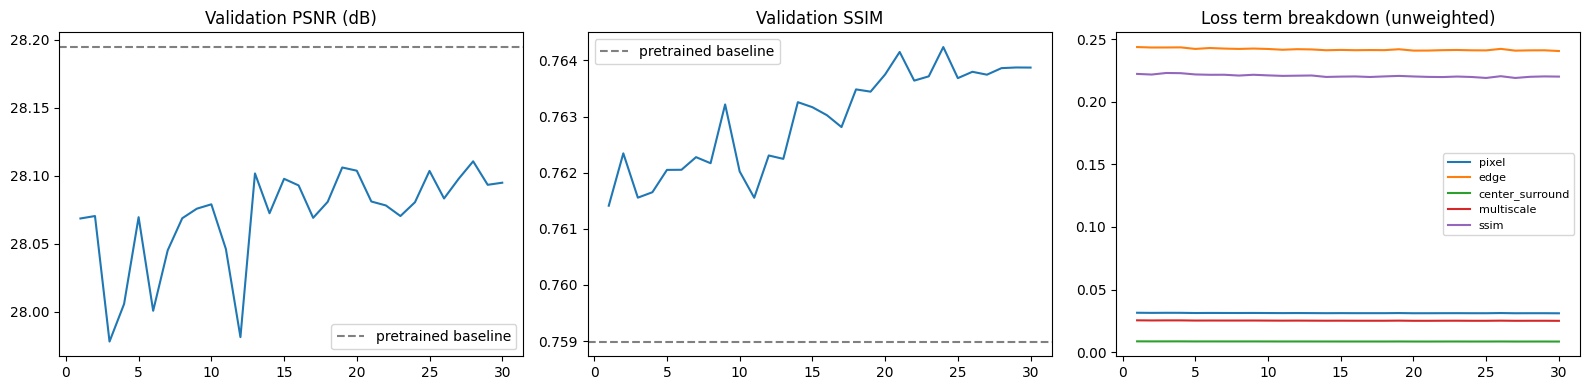

In [52]:
# ============================================================
# CELL 14 — Training Curves (incl. per-term loss breakdown)
# ============================================================
epochs_range = range(1, CONFIG['EPOCHS'] + 1)
term_names = list(final_history['term_breakdown'][0].keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(epochs_range, final_history['val_psnr']); axes[0].axhline(baseline_psnr, color='gray', linestyle='--', label='pretrained baseline')
axes[0].set_title('Validation PSNR (dB)'); axes[0].legend()
axes[1].plot(epochs_range, final_history['val_ssim']); axes[1].axhline(baseline_ssim, color='gray', linestyle='--', label='pretrained baseline')
axes[1].set_title('Validation SSIM'); axes[1].legend()
for name in term_names:
    axes[2].plot(epochs_range, [t[name] for t in final_history['term_breakdown']], label=name)
axes[2].set_title('Loss term breakdown (unweighted)'); axes[2].legend(fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/train/biomimetic_curves.png', dpi=150)
plt.show()

In [53]:
# ============================================================
# CELL 15 — Final Evaluation vs Baseline
# ============================================================
ckpt = torch.load(os.path.join(CONFIG['FINAL_CKPT_DIR'], 'best_model.pth'), map_location=device)
final_best_model = RestorationNet().to(device)
final_best_model.load_state_dict(ckpt['model_state_dict'])
final_best_model.eval()

final_final_psnr, final_final_ssim = evaluate(final_best_model, val_loader, device)
print(f"Baseline (pretrained):       PSNR {baseline_psnr:.3f} dB | SSIM {baseline_ssim:.5f}")
print(f"BioMimetic fine-tune (best): PSNR {final_final_psnr:.3f} dB | SSIM {final_final_ssim:.5f}")
print(f"Change: {final_final_psnr - baseline_psnr:+.3f} dB PSNR | {final_final_ssim - baseline_ssim:+.5f} SSIM")

Baseline (pretrained):       PSNR 28.195 dB | SSIM 0.75899
BioMimetic fine-tune (best): PSNR 28.111 dB | SSIM 0.76386
Change: -0.084 dB PSNR | +0.00487 SSIM


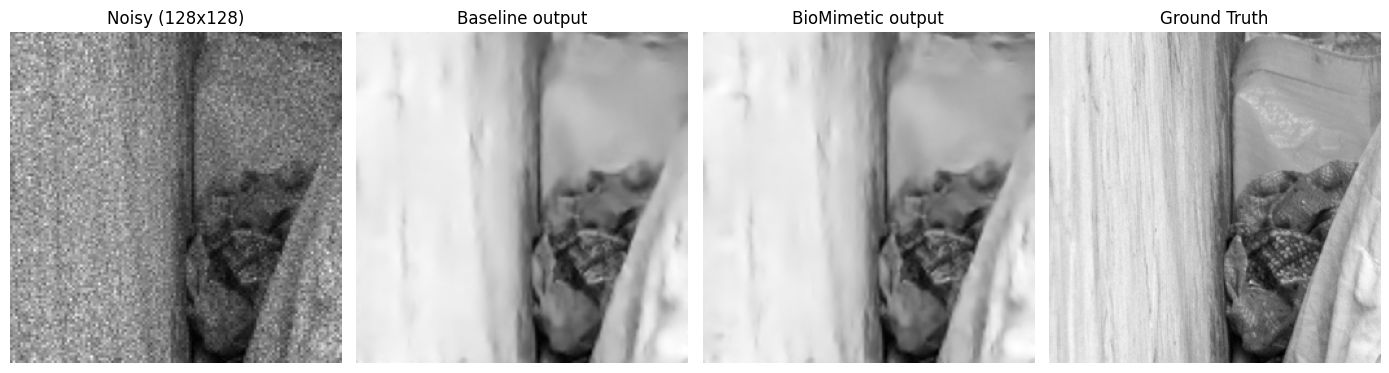

In [54]:
# ============================================================
# CELL 16 — Full 128→256 Inference, Visual Check
# ============================================================
sample_fn = val_files[0]
noisy_full = np.load(os.path.join(CONFIG['NOISY_DIR'], sample_fn)).astype(np.float32)
gt_full = np.load(os.path.join(CONFIG['GT_DIR'], sample_fn)).astype(np.float32)

inp = torch.from_numpy(noisy_full).unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad(), torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
    out_baseline = baseline_model(inp)
    out_final = final_best_model(inp)
out_baseline = out_baseline.float().clamp(0, 1).squeeze().cpu().numpy()
out_final = out_final.float().clamp(0, 1).squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(noisy_full, cmap='gray'); axes[0].set_title('Noisy (128x128)'); axes[0].axis('off')
axes[1].imshow(out_baseline, cmap='gray'); axes[1].set_title('Baseline output'); axes[1].axis('off')
axes[2].imshow(out_final, cmap='gray'); axes[2].set_title('BioMimetic output'); axes[2].axis('off')
axes[3].imshow(gt_full, cmap='gray'); axes[3].set_title('Ground Truth'); axes[3].axis('off')
plt.tight_layout(); plt.show()